In [0]:
# Install required libraries (run once)
!pip install implicit scipy scikit-learn pandas pyarrow fastparquet -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sparse
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split as sk_train_test_split
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


In [0]:
df = pd.read_parquet("/Workspace/Users/raymondlolopayung68@gmail.com/Instacart/Instacart_TrainData.parquet")

# fix tipe
df["order_hour_of_day"] = df["order_hour_of_day"].astype(int)

# implicit feedback: hanya interaksi positif
df = df[df["reordered"] == 1]

# sort untuk time-aware split
df = df.sort_values(["user_id", "order_number"])

print("Total interactions:", len(df))

Total interactions: 828824


In [0]:
# The parquet file has already been loaded into 'df' in Cell 3
# It contains combined order and product information
print("\nDataset Overview:")
print(f"  df shape: {df.shape}")
print(f"  df columns: {df.columns.tolist()}")


Dataset Overview:
  df shape: (828824, 11)
  df columns: ['order_id', 'user_id', 'product_id', 'aisle_id', 'department_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order', 'reordered']


In [0]:
# df already contains user_id and product_id from Cell 3
# Hitung frekuensi pembelian user-product (implicit feedback)
user_product_freq = (
    df.groupby(['user_id', 'product_id'])
    .size()
    .reset_index(name='purchase_count')
)

print(f"✅ User-Product interactions: {user_product_freq.shape}")
print(f"   Unique users:    {user_product_freq['user_id'].nunique():,}")
print(f"   Unique products: {user_product_freq['product_id'].nunique():,}")
print(f"   Total interactions: {len(user_product_freq):,}")
user_product_freq.head()
# ============================================================
# PENTING: Encode user_id dan product_id ke integer index
# ============================================================
user_encoder    = LabelEncoder()
product_encoder = LabelEncoder()

user_product_freq['user_idx']    = user_encoder.fit_transform(user_product_freq['user_id'])
user_product_freq['product_idx'] = product_encoder.fit_transform(user_product_freq['product_id'])

n_users    = user_product_freq['user_idx'].nunique()
n_products = user_product_freq['product_idx'].nunique()

print(f"Matrix size: {n_users:,} users × {n_products:,} products")
print(f"Sparsity: {1 - len(user_product_freq)/(n_users*n_products):.4%}")
# ============================================================
# Confidence weighting: c_ui = 1 + alpha * r_ui
# (standar untuk ALS implicit feedback - Hu et al. 2008)
# ============================================================
ALPHA = 40  # hyperparameter confidence scaling

user_product_freq['confidence'] = 1 + ALPHA * user_product_freq['purchase_count']

# Build sparse matrix (user x product)
user_item_matrix = sparse.csr_matrix(
    (
        user_product_freq['confidence'].values,
        (user_product_freq['user_idx'].values, user_product_freq['product_idx'].values)
    ),
    shape=(n_users, n_products)
)

# Item-user transpose (diperlukan oleh library implicit)
item_user_matrix = user_item_matrix.T.tocsr()

print(f"✅ Sparse matrix shape: {user_item_matrix.shape}")
print(f"   Non-zero elements: {user_item_matrix.nnz:,}")

✅ User-Product interactions: (828824, 3)
   Unique users:    122,607
   Unique products: 30,176
   Total interactions: 828,824
Matrix size: 122,607 users × 30,176 products
Sparsity: 99.9776%
✅ Sparse matrix shape: (122607, 30176)
   Non-zero elements: 828,824


In [0]:
# Create test set from df (last order per user for evaluation)
test_orders = df.groupby('user_id').tail(5)  # Last 5 items per user as test

# Filter to only users and products that exist in our encoders
valid_users = set(user_encoder.classes_)
valid_products = set(product_encoder.classes_)

test_data = test_orders[
    test_orders['user_id'].isin(valid_users) &
    test_orders['product_id'].isin(valid_products)
].copy()

test_data['user_idx'] = user_encoder.transform(test_data['user_id'])
test_data['product_idx'] = product_encoder.transform(test_data['product_id'])

# Build ground truth dict: {user_idx: set of product_idx}
ground_truth = (
    test_data.groupby('user_idx')['product_idx']
    .apply(set)
    .to_dict()
)

print(f"✅ Test users:    {len(ground_truth):,}")
print(f"   Avg items/user: {np.mean([len(v) for v in ground_truth.values()]):.2f}")

✅ Test users:    122,607
   Avg items/user: 3.82


In [0]:
# ============================================================
# ALS Hyperparameters
# Referensi: Hu, Koren & Volinsky (2008)
# "Collaborative Filtering for Implicit Feedback Datasets"
# ============================================================
ALS_PARAMS = {
    'factors':          128,    # dimensi latent factor
    'regularization':   0.01,   # regularisasi λ
    'iterations':       30,     # jumlah iterasi ALS
    'alpha':            ALPHA,  # confidence scaling (sudah dipakai di matrix)
    'use_gpu':          False,  # set True jika ada GPU
    'random_state':     42,
    'num_threads':      4,
}

print("🔧 ALS Configuration:")
for k, v in ALS_PARAMS.items():
    print(f"   {k}: {v}")

# Inisialisasi model
model = AlternatingLeastSquares(
    factors=ALS_PARAMS['factors'],
    regularization=ALS_PARAMS['regularization'],
    iterations=ALS_PARAMS['iterations'],
    use_gpu=ALS_PARAMS['use_gpu'],
    random_state=ALS_PARAMS['random_state'],
    num_threads=ALS_PARAMS['num_threads'],
)

print("\n🚀 Training ALS model...")
start_time = time.time()

# Training: input adalah item-user matrix
model.fit(item_user_matrix)

elapsed = time.time() - start_time
print(f"✅ Training completed in {elapsed:.1f} seconds")

🔧 ALS Configuration:
   factors: 128
   regularization: 0.01
   iterations: 30
   alpha: 40
   use_gpu: False
   random_state: 42
   num_threads: 4

🚀 Training ALS model...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Training completed in 52.2 seconds


In [0]:
def ndcg_at_k(recommended, relevant, k):
    """
    NDCG@K - Normalized Discounted Cumulative Gain
    
    Formula:
        DCG@K  = sum_{i=1}^{K} rel_i / log2(i+1)
        IDCG@K = DCG dari ranking ideal
        NDCG@K = DCG@K / IDCG@K
    
    Args:
        recommended: list of recommended item indices (ordered)
        relevant:    set of ground truth item indices
        k:           cutoff
    Returns:
        float in [0, 1]
    """
    recommended_k = recommended[:k]
    
    # DCG
    dcg = 0.0
    for i, item in enumerate(recommended_k):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)  # i+2 karena i 0-indexed
    
    # IDCG (ideal DCG): semua item relevan di posisi teratas
    n_relevant_in_k = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(n_relevant_in_k))
    
    return dcg / idcg if idcg > 0 else 0.0


def mrr_at_k(recommended, relevant, k):
    """
    MRR@K - Mean Reciprocal Rank
    
    Formula:
        RR = 1 / rank_of_first_relevant_item
        MRR = mean(RR) across all users
    
    Args:
        recommended: list of recommended item indices (ordered)
        relevant:    set of ground truth item indices
        k:           cutoff
    Returns:
        float in [0, 1]
    """
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            return 1.0 / (i + 1)
    return 0.0


def recall_at_k(recommended, relevant, k):
    """
    Recall@K
    
    Formula:
        Recall@K = |recommended[:K] ∩ relevant| / |relevant|
    
    Args:
        recommended: list of recommended item indices (ordered)
        relevant:    set of ground truth item indices
        k:           cutoff
    Returns:
        float in [0, 1]
    """
    recommended_k = set(recommended[:k])
    hits = len(recommended_k & relevant)
    return hits / len(relevant) if len(relevant) > 0 else 0.0


print("✅ Evaluation functions defined: NDCG@K, MRR@K, Recall@K")

✅ Evaluation functions defined: NDCG@K, MRR@K, Recall@K


In [0]:
def evaluate_model(model, user_item_matrix, ground_truth, K_values=[5, 10, 20], 
                   sample_size=None, verbose=True):
    """
    Evaluate ALS model dengan NDCG@K, MRR@K, Recall@K.
    
    Args:
        model:            trained ALS model
        user_item_matrix: sparse user-item matrix (CSR)
        ground_truth:     dict {user_idx: set(product_idx)}
        K_values:         list of K cutoffs
        sample_size:      jumlah user yang dievaluasi (None = semua)
        verbose:          print progress
    Returns:
        pd.DataFrame hasil evaluasi
    """
    test_users = list(ground_truth.keys())
    if sample_size and sample_size < len(test_users):
        np.random.seed(42)
        test_users = np.random.choice(test_users, size=sample_size, replace=False).tolist()
    
    max_k = max(K_values)
    
    # Akumulator
    results = {k: {'ndcg': [], 'mrr': [], 'recall': []} for k in K_values}
    
    print(f"🔍 Evaluating {len(test_users):,} users with K={K_values}...")
    start = time.time()
    
    for i, user_idx in enumerate(test_users):
        if verbose and (i+1) % 5000 == 0:
            print(f"   Progress: {i+1:,}/{len(test_users):,} users ({(i+1)/len(test_users)*100:.1f}%)")
        
        relevant = ground_truth[user_idx]
        if not relevant:
            continue
        
        # Generate top-K recommendations
        # filter_already_liked=True → exclude items already in training
        try:
            recommended_ids, _ = model.recommend(
                user_idx,
                user_item_matrix[user_idx],
                N=max_k,
                filter_already_liked_items=True
            )
        except Exception:
            continue
        
        rec_list = recommended_ids.tolist()
        
        for k in K_values:
            results[k]['ndcg'].append(ndcg_at_k(rec_list, relevant, k))
            results[k]['mrr'].append(mrr_at_k(rec_list, relevant, k))
            results[k]['recall'].append(recall_at_k(rec_list, relevant, k))
    
    elapsed = time.time() - start
    print(f"✅ Evaluation done in {elapsed:.1f}s")
    
    # Compile results
    rows = []
    for k in K_values:
        rows.append({
            'K':         k,
            'NDCG@K':    np.mean(results[k]['ndcg']),
            'MRR@K':     np.mean(results[k]['mrr']),
            'Recall@K':  np.mean(results[k]['recall']),
            'n_users':   len(results[k]['ndcg']),
        })
    
    return pd.DataFrame(rows)


# Jalankan evaluasi (gunakan sample_size untuk mempercepat jika data besar)
eval_results = evaluate_model(
    model=model,
    user_item_matrix=user_item_matrix,
    ground_truth=ground_truth,
    K_values=[5, 10, 20],
    sample_size=10000,  # set None untuk semua user
    verbose=True
)
# ============================================================
# Tampilkan hasil evaluasi
# ============================================================
print("="*55)
print("📊 ALS RECOMMENDATION SYSTEM — EVALUATION RESULTS")
print("="*55)
print(eval_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*55)

🔍 Evaluating 10,000 users with K=[5, 10, 20]...
   Progress: 5,000/10,000 users (50.0%)
   Progress: 10,000/10,000 users (100.0%)
✅ Evaluation done in 10.1s
📊 ALS RECOMMENDATION SYSTEM — EVALUATION RESULTS
 K  NDCG@K  MRR@K  Recall@K  n_users
 5  0.0000 0.0000    0.0000     2519
10  0.0000 0.0000    0.0000     2519
20  0.0000 0.0000    0.0000     2519


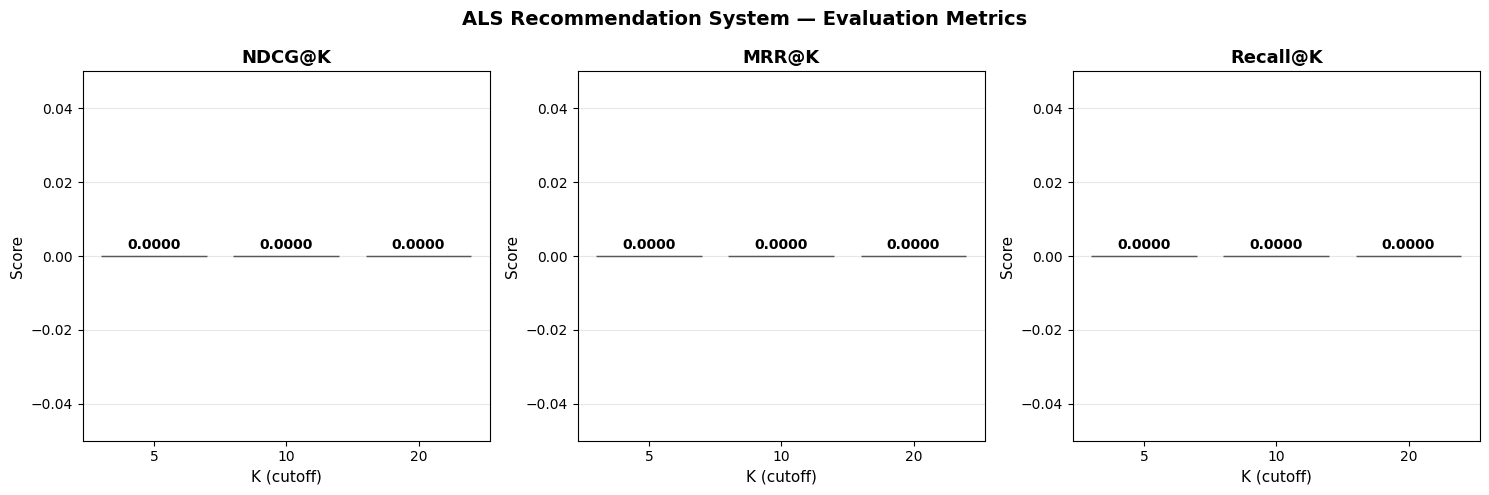

✅ Plot saved: als_evaluation_metrics.png


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ALS Recommendation System — Evaluation Metrics', fontsize=14, fontweight='bold')

metrics = ['NDCG@K', 'MRR@K', 'Recall@K']
colors  = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(eval_results['K'].astype(str), eval_results[metric], color=color, alpha=0.8, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('K (cutoff)', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, eval_results[metric].max() * 1.2)
    for i, (k, v) in enumerate(zip(eval_results['K'], eval_results[metric])):
        ax.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('als_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: als_evaluation_metrics.png")

In [0]:
# ============================================================
# Grid search atas faktor & regularisasi
# Uncomment dan jalankan untuk tuning (membutuhkan waktu lebih lama)
# ============================================================

def grid_search_als(item_user_matrix, user_item_matrix, ground_truth,
                    factors_list, reg_list, iterations=20, K=10, sample_size=3000):
    """
    Grid search ALS hyperparameters berdasarkan NDCG@K.
    """
    best_score = -1
    best_params = {}
    results = []
    
    total = len(factors_list) * len(reg_list)
    counter = 0
    
    for factors in factors_list:
        for reg in reg_list:
            counter += 1
            print(f"[{counter}/{total}] factors={factors}, reg={reg}")
            
            m = AlternatingLeastSquares(
                factors=factors,
                regularization=reg,
                iterations=iterations,
                use_gpu=False,
                random_state=42
            )
            m.fit(item_user_matrix, show_progress=False)
            
            df = evaluate_model(m, user_item_matrix, ground_truth,
                                K_values=[K], sample_size=sample_size, verbose=False)
            score = df[df['K'] == K]['NDCG@K'].values[0]
            
            results.append({'factors': factors, 'regularization': reg, f'NDCG@{K}': score})
            print(f"   NDCG@{K} = {score:.4f}")
            
            if score > best_score:
                best_score = score
                best_params = {'factors': factors, 'regularization': reg}
    
    print(f"\n🏆 Best params: {best_params} | NDCG@{K} = {best_score:.4f}")
    return pd.DataFrame(results), best_params


# UNCOMMENT untuk menjalankan grid search:
# gs_results, best_params = grid_search_als(
#     item_user_matrix   = item_user_matrix,
#     user_item_matrix   = user_item_matrix,
#     ground_truth       = ground_truth,
#     factors_list       = [64, 128, 256],
#     reg_list           = [0.001, 0.01, 0.1],
#     iterations         = 20,
#     K                  = 10,
#     sample_size        = 3000,
# )
# print(gs_results.to_string(index=False))

print("⏸️  Grid search cell ready — uncomment to run")

⏸️  Grid search cell ready — uncomment to run


In [0]:
def get_user_recommendations(user_id_original, model, user_item_matrix,
                              user_encoder, product_encoder, N=10):
    """
    Tampilkan rekomendasi produk untuk satu user.
    """
    if user_id_original not in set(user_encoder.classes_):
        print(f"User {user_id_original} tidak ditemukan di training data.")
        return None
    
    user_idx = user_encoder.transform([user_id_original])[0]
    
    rec_ids, scores = model.recommend(
        user_idx,
        user_item_matrix[user_idx],
        N=N,
        filter_already_liked_items=True
    )
    
    # Filter to only valid product indices
    max_product_idx = len(product_encoder.classes_) - 1
    valid_mask = rec_ids <= max_product_idx
    rec_ids = rec_ids[valid_mask]
    scores = scores[valid_mask]
    
    if len(rec_ids) == 0:
        print(f"No valid recommendations for user {user_id_original}")
        return None
    
    rec_product_ids = product_encoder.inverse_transform(rec_ids)
    
    recs = pd.DataFrame({
        'rank':       range(1, len(rec_ids)+1),
        'product_id': rec_product_ids,
        'score':      scores
    })
    
    print(f"\n🛒 Top-{len(rec_ids)} Recommendations for User {user_id_original}:")
    print(recs[['rank', 'product_id', 'score']].to_string(index=False))
    return recs


# Ambil sample user dari test set
sample_user_idx = list(ground_truth.keys())[0]
sample_user_id  = user_encoder.inverse_transform([sample_user_idx])[0]

recs = get_user_recommendations(
    user_id_original = sample_user_id,
    model            = model,
    user_item_matrix = user_item_matrix,
    user_encoder     = user_encoder,
    product_encoder  = product_encoder,
    N                = 10
)


🛒 Top-3 Recommendations for User 1:
 rank  product_id    score
    1        1477 0.773024
    2       48902 0.753800
    3       44873 0.725714
